# **TRABAJO SEMANAL 2: MODELIZANDO UN ADC**
## ALUMNA: Maylen Monterde

### **INTRODUCCIÓN**
Un ADC (conversor analógico-digital) permite representar una señal continua en el tiempo y en amplitud mediante un conjunto finito de valores discretos, aptos para ser procesados digitalmente. Uno de los procesos que ocurre en la conversión es la cuantización donde cada muestra de la señal de entrada es aproximada al escalón permitido más cercano, definido como el paso de cuantización q, que depende tanto del rango dinámico del conversor $\pm Vf$ como de la cantidad de bits $B$ disponibles para representar la señal.
Como el ADC solo puede representar una cantidad finita de niveles, esta aproximación introduce una diferencia entre el valor real de la señal y de su versión cuantizada. A esto se lo conoce como ruido de cuantización $e_q$.
Además del ruido de cuantización, hay un ruido analógico que viene en la señal de entrada. Este ruido presenta una distribución Gaussiana e incorrelada. Hay una relación entre la potencia de ruido analógico $P_n$ y la potencia del ruido de cuantización $P_q = q²/12$. La relación es:
$P_n = k_n * P_q$
Donde $k_n$ es un factor de escala y es en donde nos vamos a enfocar en este trabajo. 
La idea principal de este trabajo es analizar cómo cambian estas señales (las señales digitales) a partir de la variación del factor de escala $k_n$ y de la cantidad de bits que permite el ADC.

### *RESOLUCIÓN:*
Se considera una señal senoidal de energía unitaria, con una frecuencia muestral $f_s=1000$ y $N=1000$ muestras, dentro de un rango de $\pm Vf=2V$.
A partir de esta señal se simula el conversor analógico-digital:
- se calcula el ruido analógico
- se calcula el factor de cuantización $q$
- se calcula la señal cuantizada y su error asociado

Luego, se analiza para una cantidad de bits fijas qué ocurre si se varía el factor de escala.
**comentario**: se optó por fijar la cantidad de bits para poder aislar el efecto de $k_n$ sobre el sistema.

- Primero, defino las librerias y las funciones que se utilizarán en todo el trabajo

In [20]:
## TS2 - MODELIZANDO UN ADC
#%% LIBRERIAS
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest

#%% 1. FUNCIONES
def funcion_sen(A=1, Vmed=0, ff=1, phi=0, N=1000, fs=1000):
    tt = np.arange(N) / fs #arranca en 0 y termina en N-1 y eso se divide por la frecuencia de muestreo
    xx = A * np.sin(2 * np.pi * ff * tt + phi) + Vmed
    return tt, xx

# para simplificar código se creó una función donde calcule todo lo necesario para graficar en el dominio de la frecuencia
def espectro_normalizado_dB(señal, referencia_dB, eps=1e-12):
    #Calcula la FFT física (2/N, corrige DC), la recorta a Nyquist, pasa a dB y referencia a 0dB
    fft_fis = (2 / N) * np.fft.fft(señal) #ya está normalizada
    fft_fis[0] = fft_fis[0] / 2  # Corrección de la componente continua
    modulo = np.abs(fft_fis)[:corte]
    modulo_dB = 20 * np.log10(np.maximum(modulo, eps))
    return modulo_dB - referencia_dB

#%% 2. PARÁMETROS GENERALES
Ps = 1 # potencia de la senoidal (normalizada a 1W)
Amplitud = np.sqrt(2 * Ps)
Vmed = 0
phi = 0
N = 1000
fs = 1000
ff = fs / N  # 1 ciclo completo en las N muestras

### **CASO 1 :** *B = 4 bits*


 -------- FACTOR DE ESCALA: 0.1 --------

Varianza medida de e_n: 5.908e-03 V²  |  Teórica (q²/12): 5.208e-03 V²
KS statistic = 0.0491  |  p-value = 0.0155
→ Se rechaza H0: el error NO parece uniforme


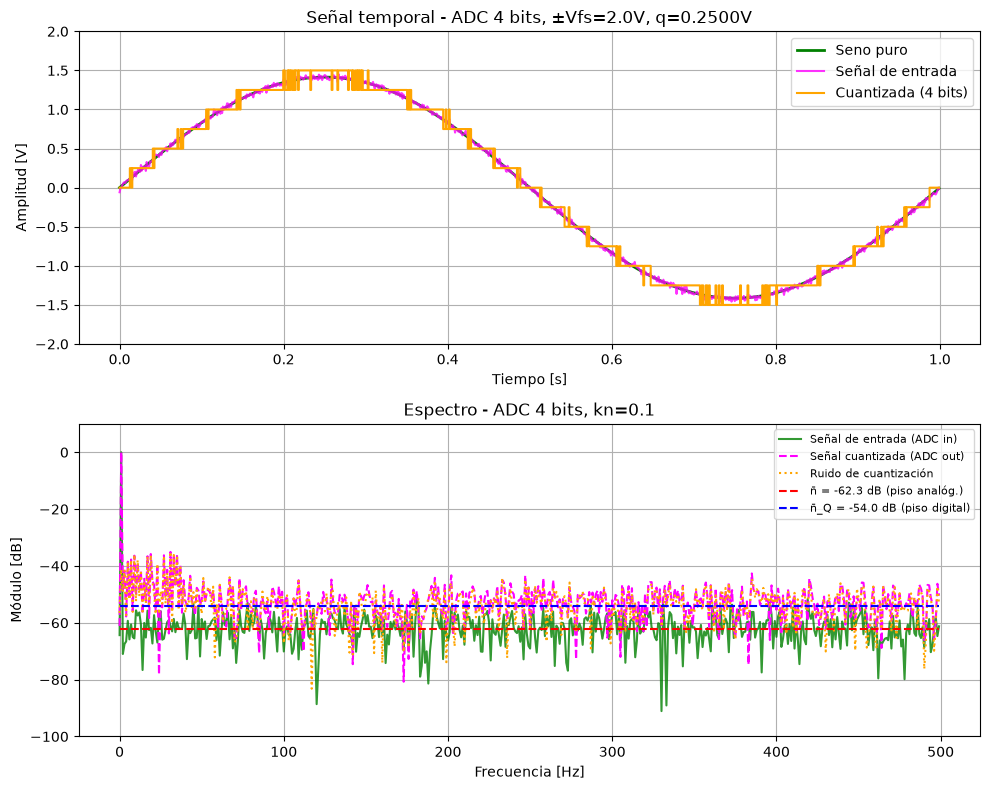

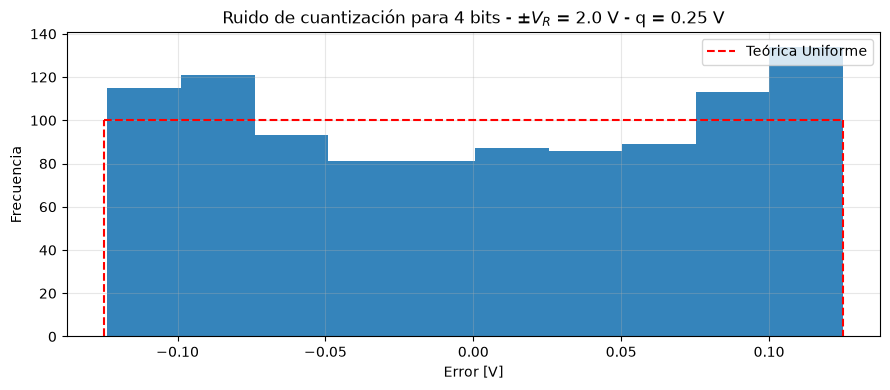

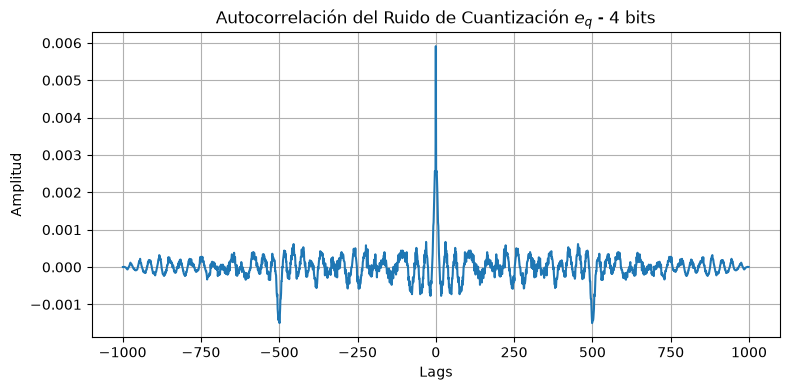

SNR Real del sistema: 21.76 dB

 -------- FACTOR DE ESCALA: 1 --------

Varianza medida de e_n: 5.403e-03 V²  |  Teórica (q²/12): 5.208e-03 V²
KS statistic = 0.0312  |  p-value = 0.2793
→ No se rechaza H0: el error es compatible con U(-q/2, q/2)


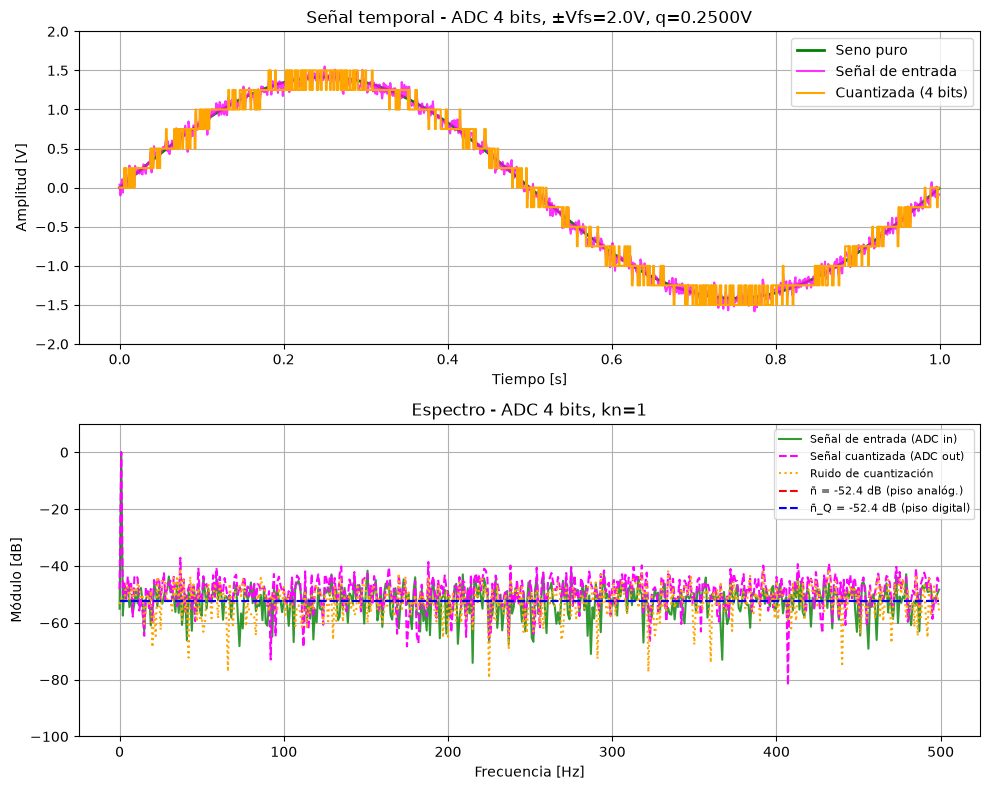

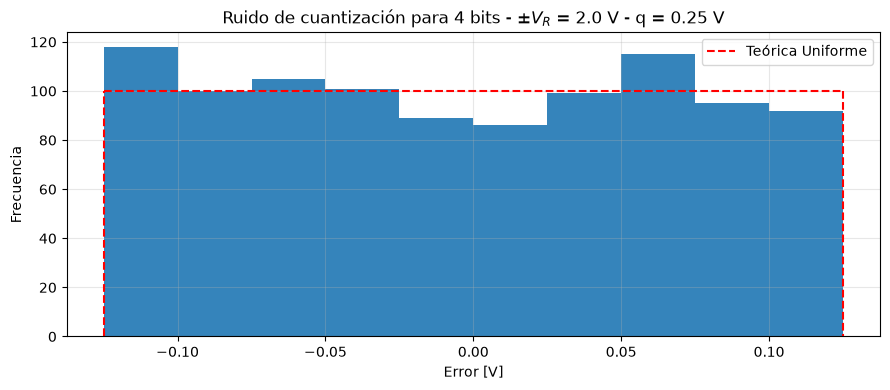

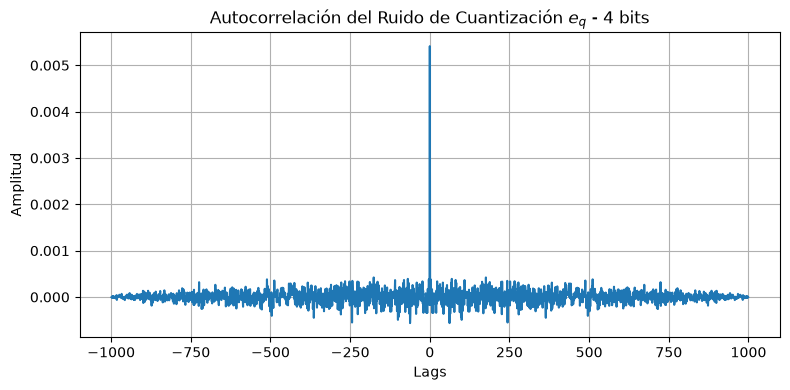

SNR Real del sistema: 19.60 dB

 -------- FACTOR DE ESCALA: 10 --------

Varianza medida de e_n: 5.126e-03 V²  |  Teórica (q²/12): 5.208e-03 V²
KS statistic = 0.0196  |  p-value = 0.8308
→ No se rechaza H0: el error es compatible con U(-q/2, q/2)


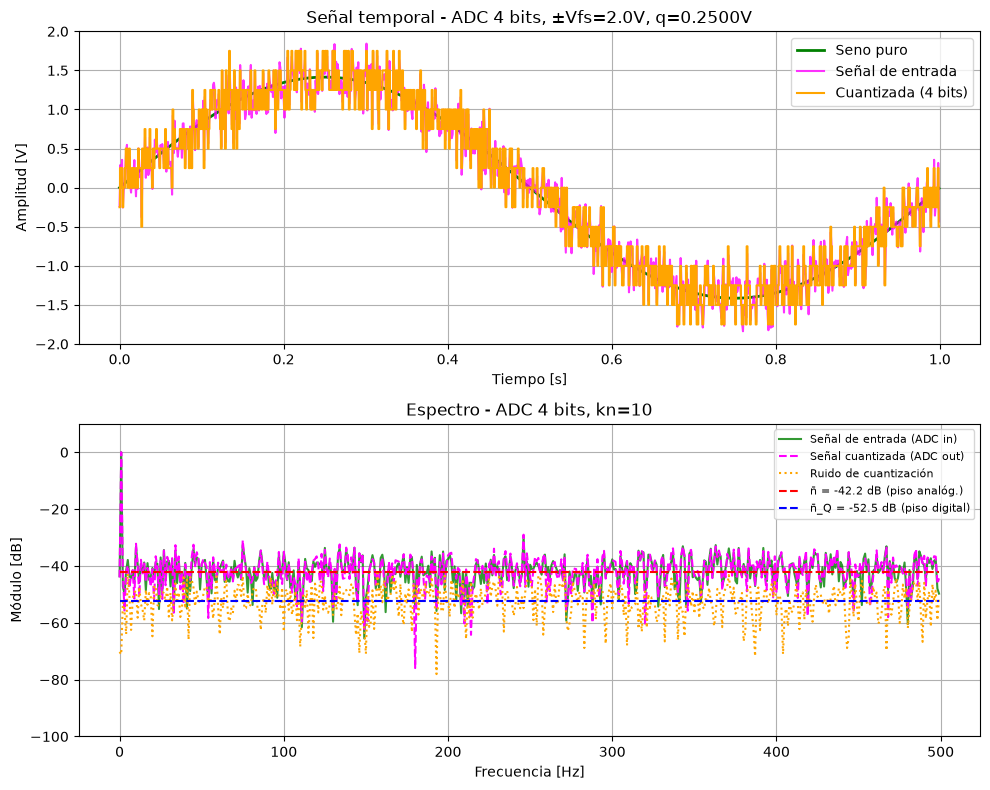

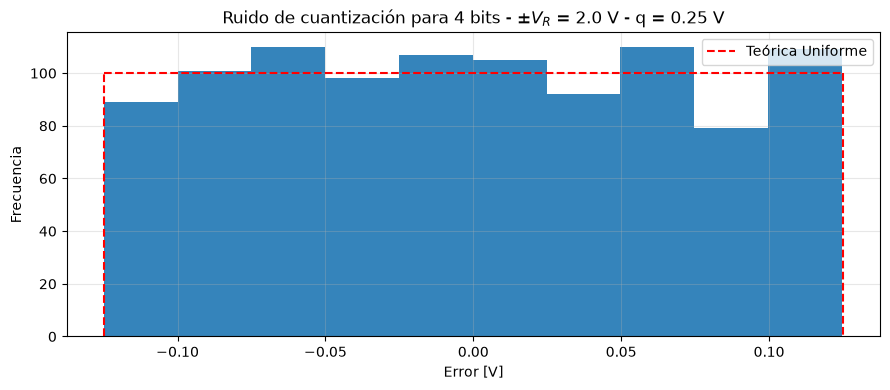

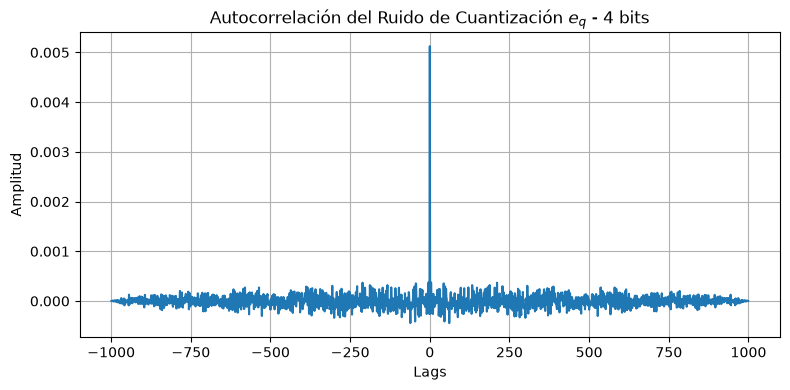

SNR Real del sistema: 12.54 dB


,kn,Var. medida e_n [V²],Var. teórica q²/12 [V²],KS p-value,SNR [dB]
0,0.1,5.908e-03,5.208e-03,0.0155,21.76
1,1.0,5.403e-03,5.208e-03,0.2793,19.60
2,10.0,5.126e-03,5.208e-03,0.8308,12.54


In [21]:
## CASO 1:
resultados_B4 = []
#parametros cuantización
B = 4                   # bits del ADC
kn = [0.1, 1, 10]       # factor k: relación pot. analógica / pot. cuantización
Vfs = 2.0               # rango de fondo de escala (+-Vfs)

#%% 3. SEÑAL DE ENTRADA - CUANTIZACIÓN
# acá solo calculo las señales
tt, xx = funcion_sen(Amplitud, Vmed, ff, phi, N, fs)

# para poder recorrer todo realizo un for (que vaya haciendo los distintos gráficos, los bits lo cambio a mano)
# seguramente haya otras maneras más prolijas de solucionarlo
for i in kn:
    
    print(f"\n -------- FACTOR DE ESCALA: {i} --------\n")
    
    # mido el paso de cuantización y su potencia para calcular Pruido
    q = 2 * Vfs / (2**B)
    Pq = (q**2) / 12
    Pruido = i * Pq #relacion que nos la dan en la consigna

    # Ruido analógico
    # calculo el vector ruido Gaussiano e incorrelado: (media 0,  varianza = la raíz de Pn, cant de muestras a generar)
    dv = np.sqrt(Pruido)
    ruido = np.random.normal(0, dv, N)
    
    # Entrada al ADC con saturación
    señal_entrada = xx + ruido
    señal_sat = np.clip(señal_entrada, -Vfs, Vfs) #recorta/limita los valores de un vector para que queden dentro de ese rango
    
    # Cuantización y error
    # lo del ( ) me dice cuantos pasos q entran en la señal, lo redondeo y vuelvo a volts donde el valor puede ser un multiplo entero de q
    # xx_cuantizada ya no es continua, vale: -2q, -q, 0, q, 2q, ...
    xx_q = np.round(señal_sat / q) * q
    e_n = xx_q - señal_sat
    
    #%% 4. DOMINIO FRECUENCIAS
    # paso al dominio de frecuencias (para poder graficar):
    frecuencias = np.fft.fftfreq(N, 1/fs)
    corte = N // 2
    frec_nyquist = frecuencias[:corte]
    
    # Tomamos como referencia el pico máximo de la señal de entrada al ADC
    fft_entrada_fis = (2 / N) * np.fft.fft(señal_sat)
    fft_entrada_fis[0] = fft_entrada_fis[0] / 2
    modulo_entrada_dB_bruto = 20 * np.log10(np.maximum(np.abs(fft_entrada_fis)[:corte], 1e-12))
    max_referencia = np.max(modulo_entrada_dB_bruto)
    
    # Obtenemos los espectros normalizados para cada señal
    modulo_entrada = espectro_normalizado_dB(señal_sat, max_referencia)
    modulo_ruido_analog = espectro_normalizado_dB(ruido, max_referencia)
    modulo_señalcuanti = espectro_normalizado_dB(xx_q, max_referencia)
    modulo_ruidocuanti = espectro_normalizado_dB(e_n, max_referencia)

    # Pisos de ruido (promediando sin incluir la continua en el índice 0)
    piso_analogico = np.mean(modulo_ruido_analog[1:]) #solo indica que se saltee el 0
    piso_digital = np.mean(modulo_ruidocuanti[1:])
    
    # --- Verificación estadística del error de cuantización ---
    var_medida = np.var(e_n)
    print(f"Varianza medida de e_n: {var_medida:.3e} V²  |  Teórica (q²/12): {Pq:.3e} V²")

    resultado = kstest(e_n, 'uniform', args=(-q/2, q))
    print(f"KS statistic = {resultado.statistic:.4f}  |  p-value = {resultado.pvalue:.4f}")
    if resultado.pvalue > 0.05:
        print("→ No se rechaza H0: el error es compatible con U(-q/2, q/2)")
    else:
        print("→ Se rechaza H0: el error NO parece uniforme")
    
    #%% 5. GRÁFICO 1: DOMINIO TIEMPO
    plt.figure(figsize=(10, 8))
    plt.subplot(2, 1, 1)
    plt.plot(tt, xx, label='Seno puro', color='green', linestyle='-', linewidth=2)
    plt.plot(tt, señal_sat, label='Señal de entrada', color='magenta', linestyle='-', markersize=3, alpha=0.8)
    plt.step(tt, xx_q, where='mid', label=f'Cuantizada ({B} bits)', color='orange', linewidth=1.5)
    plt.title(f"Señal temporal - ADC {B} bits, ±Vfs={Vfs}V, q={q:.4f}V")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Amplitud [V]")
    plt.ylim(-Vfs, Vfs)
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.tight_layout()
    
    #%% 6. GRÁFICO 2: ESPECTRO EN FRECUENCIA [dB]
    plt.subplot(2, 1, 2)
    plt.plot(frec_nyquist, modulo_entrada, label='Señal de entrada (ADC in)', color='green', alpha=0.8)
    plt.plot(frec_nyquist, modulo_señalcuanti, label='Señal cuantizada (ADC out)', linestyle='--', color='magenta')
    plt.plot(frec_nyquist, modulo_ruidocuanti, label='Ruido de cuantización', linestyle=':', color='orange')
    plt.plot(frec_nyquist, [piso_analogico]*len(frec_nyquist), linestyle='--', color='red', label=f'n̄ = {piso_analogico:.1f} dB (piso analóg.)')
    plt.plot(frec_nyquist, [piso_digital]*len(frec_nyquist), linestyle='--', color='blue', label=f'n̄_Q = {piso_digital:.1f} dB (piso digital)')

    plt.title(f'Espectro - ADC {B} bits, kn={i}')
    plt.xlabel('Frecuencia [Hz]')
    plt.ylabel('Módulo [dB]')
    plt.legend(fontsize=8, loc='upper right')
    plt.ylim(-100, 10)
    plt.grid(True)
    plt.tight_layout()
    
    #%% 7. GRAFICO 3: HISTOGRAMA DEL ERROR DE CUANTIZACIÓN
    plt.figure(figsize=(9, 4))

    # 1. Histograma de los errores (usamos 10 bins para mejorar el grafico)
    count, bins, ignored = plt.hist(e_n, bins=10, color='tab:blue', alpha=0.9)

    # 2. Dibujamos la caja roja teórica de la distribución uniforme U(-q/2, q/2)
    # La altura teórica de las cuentas por bin es el total de muestras (nn) dividido la cantidad de bins (10)
    altura_teorica = N / 10

    plt.plot([-q/2, -q/2], [0, altura_teorica], color='red', linestyle='--')
    plt.plot([-q/2,  q/2], [altura_teorica, altura_teorica], color='red', linestyle='--', label='Teórica Uniforme')
    plt.plot([ q/2,  q/2], [altura_teorica, 0], color='red', linestyle='--')

    plt.title(f"Ruido de cuantización para {B} bits - $\pm V_R$ = {Vfs} V - q = {q:} V")
    plt.xlabel("Error [V]")
    plt.ylabel("Frecuencia")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    #%% 8. GRÁFICO 4: AUTOCORRELACIÓN DEL RUIDO DE CUANTIZACIÓN
    plt.figure(figsize=(8, 4))

    r_eq = np.correlate(e_n, e_n, mode='full') / N
    lags = np.arange(-N + 1, N)

    plt.plot(lags, r_eq)
    plt.title(f'Autocorrelación del Ruido de Cuantización $e_q$ - {B} bits')
    plt.xlabel('Lags')
    plt.ylabel('Amplitud')
    plt.grid(True)

    plt.tight_layout()
    plt.show()
    
    #%% 9. SNR:
    e_total = xx_q - xx
    P_s = np.mean(xx**2)
    P_e_total = np.mean(e_total**2)

    SNR_real = 10 * np.log10(P_s / P_e_total)

    print(f"SNR Real del sistema: {SNR_real:.2f} dB")
    
    resultados_B4.append({
    "kn": i,
    "Var. medida e_n [V²]": var_medida,
    "Var. teórica q²/12 [V²]": Pq,
    "KS p-value": resultado.pvalue,
    "SNR [dB]": SNR_real
    })
        
import pandas as pd

tabla = pd.DataFrame(resultados_B4)
tabla   # sin print — Jupyter la muestra como tabla directamente

tabla_mostrar = tabla.copy()
tabla_mostrar["Var. medida e_n [V²]"] = tabla_mostrar["Var. medida e_n [V²]"].map(lambda x: f"{x:.3e}")
tabla_mostrar["Var. teórica q²/12 [V²]"] = tabla_mostrar["Var. teórica q²/12 [V²]"].map(lambda x: f"{x:.3e}")
tabla_mostrar["KS p-value"] = tabla_mostrar["KS p-value"].round(4)
tabla_mostrar["SNR [dB]"] = tabla_mostrar["SNR [dB]"].round(2)
tabla_mostrar


#### Se puede observar:
- En el dominio del tiempo se puede observar que la curva cuantizada se aleja cada vez más del seno a medida que aumenta el factor de escala. Sin embargo, esto no se debe a un aumento del error de cuantización (ya que como se puede ver en la tabla la varianza medida se mantiene constante coincidiendo con el valor teórico), sino que el cuantizador está digitalizando una señal de entrada cada vez con más ruido analógico. Entonces, lo que crece en el gráfico es el ruido analógico, no el error propio del redondeo.
- En el dominio de la frecuencia, el piso que varía notablemente entre los tres casos es el piso analógico $(-62,2 ; -52,3 ; -42,1 dB)$, mientras que el piso digital (ruido de cuantización) permanece prácticamente constante y esto es esperable debido a que la cantidad de bits no cambia. Esto confirma que $k_n$ modula la potencia del ruido analógico, no la del ruido de cuantización.
- Para el caso de $k_n=0,1$ se rechaza la hipótesis de uniformidad del error de cuantización, es decir, ese error deja de comportarse como ruido aleatorio y aparece como una distorsión armónica en el espectro.

### **CASO 2 :** *B = 8 bits*


 -------- FACTOR DE ESCALA: 0.1 --------

Varianza medida de e_n: 2.131e-05 V²  |  Teórica (q²/12): 2.035e-05 V²
KS statistic = 0.0307  |  p-value = 0.2967
→ No se rechaza H0: el error es compatible con U(-q/2, q/2)


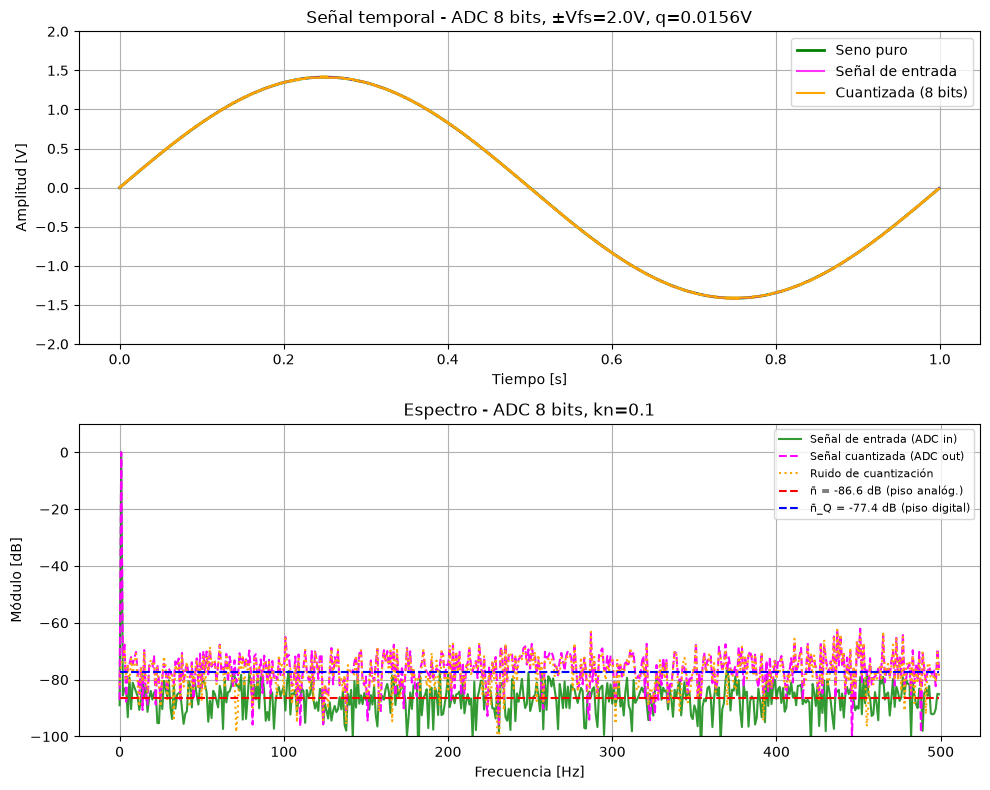

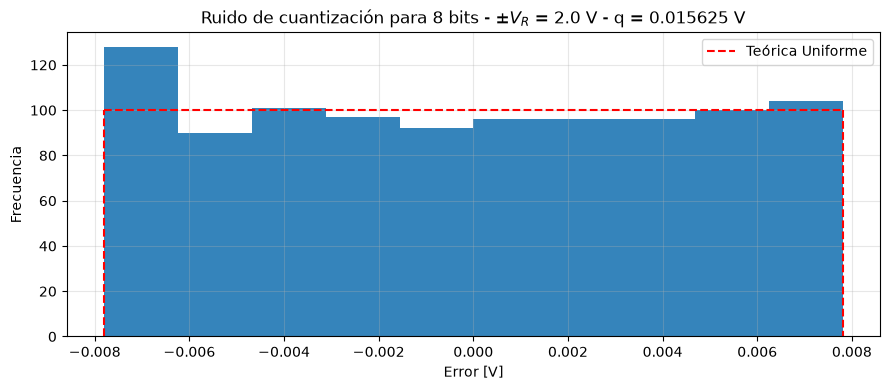

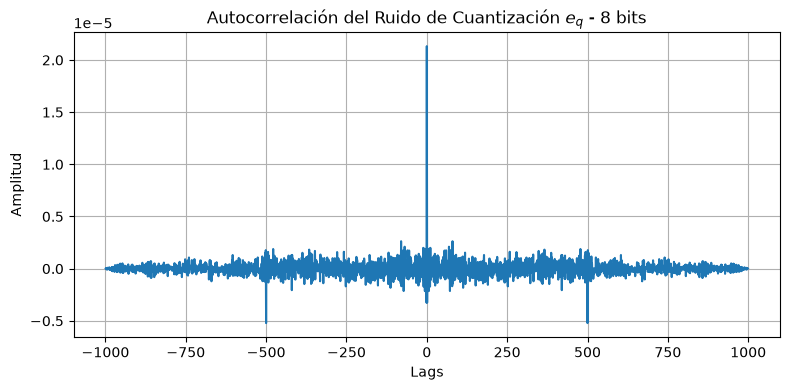

SNR Real del sistema: 46.27 dB

 -------- FACTOR DE ESCALA: 1 --------

Varianza medida de e_n: 2.006e-05 V²  |  Teórica (q²/12): 2.035e-05 V²
KS statistic = 0.0211  |  p-value = 0.7583
→ No se rechaza H0: el error es compatible con U(-q/2, q/2)


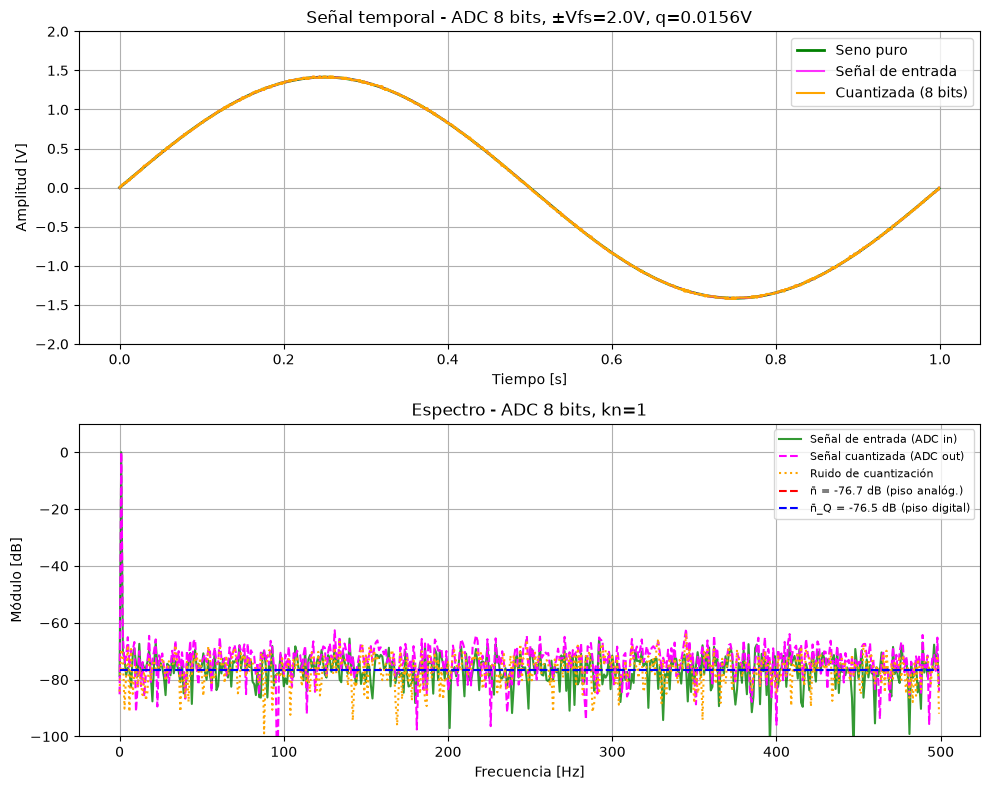

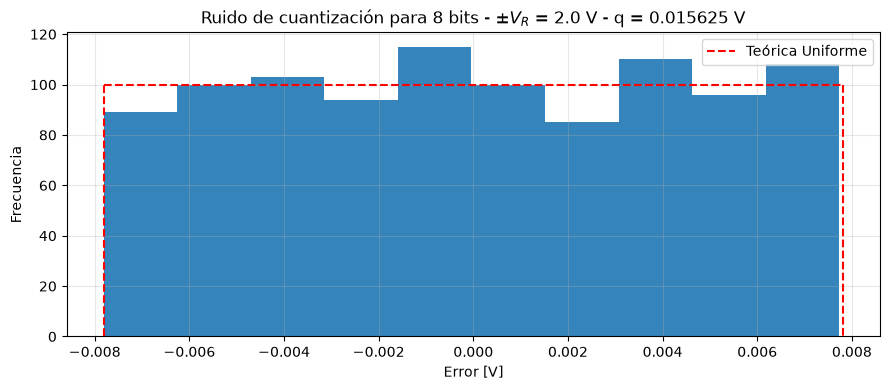

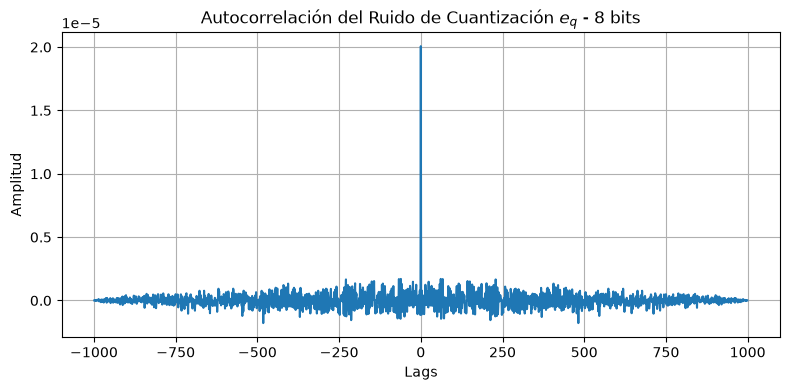

SNR Real del sistema: 43.78 dB

 -------- FACTOR DE ESCALA: 10 --------

Varianza medida de e_n: 2.091e-05 V²  |  Teórica (q²/12): 2.035e-05 V²
KS statistic = 0.0226  |  p-value = 0.6791
→ No se rechaza H0: el error es compatible con U(-q/2, q/2)


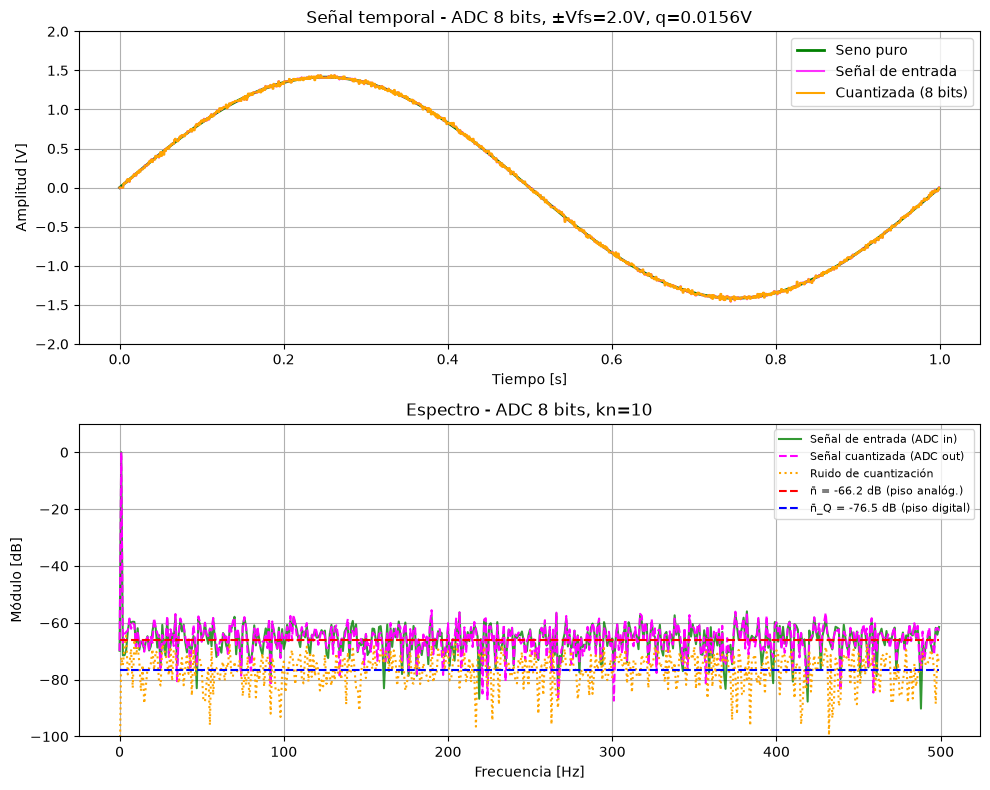

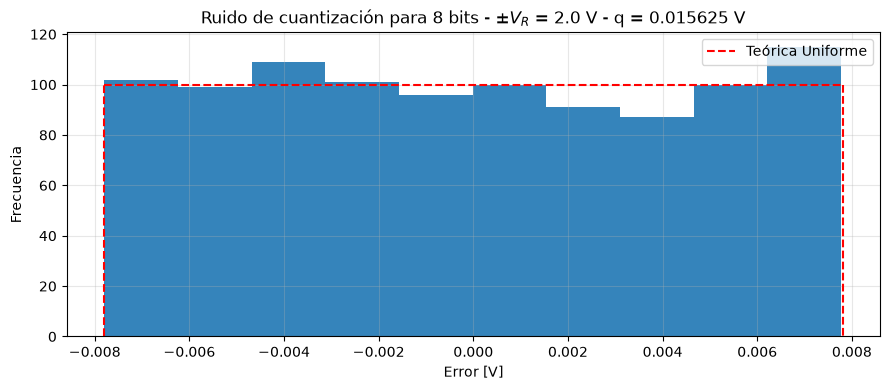

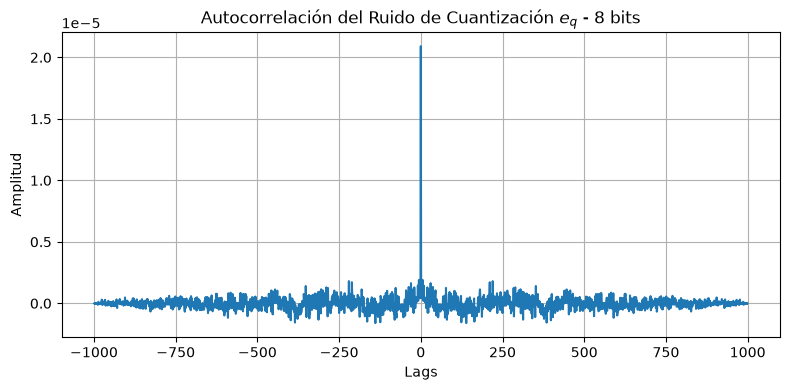

SNR Real del sistema: 36.52 dB


,kn,Var. medida e_n [V²],Var. teórica q²/12 [V²],KS p-value,SNR [dB]
0,0.1,2.131e-05,2.035e-05,0.2967,46.27
1,1.0,2.006e-05,2.035e-05,0.7583,43.78
2,10.0,2.091e-05,2.035e-05,0.6791,36.52


In [22]:
## CASO 2:
resultados_B8 = []
#parametros cuantización
B = 8                   # bits del ADC
kn = [0.1, 1, 10]       # factor k: relación pot. analógica / pot. cuantización
Vfs = 2.0               # rango de fondo de escala (+-Vfs)

#%% 3. SEÑAL DE ENTRADA - CUANTIZACIÓN
# acá solo calculo las señales
tt, xx = funcion_sen(Amplitud, Vmed, ff, phi, N, fs)

# para poder recorrer todo realizo un for (que vaya haciendo los distintos gráficos, los bits lo cambio a mano)
# seguramente haya otras maneras más prolijas de solucionarlo
for i in kn:
    
    print(f"\n -------- FACTOR DE ESCALA: {i} --------\n")
    
    # mido el paso de cuantización y su potencia para calcular Pruido
    q = 2 * Vfs / (2**B)
    Pq = (q**2) / 12
    Pruido = i * Pq #relacion que nos la dan en la consigna

    # Ruido analógico
    # calculo el vector ruido Gaussiano e incorrelado: (media 0,  varianza = la raíz de Pn, cant de muestras a generar)
    dv = np.sqrt(Pruido)
    ruido = np.random.normal(0, dv, N)
    
    # Entrada al ADC con saturación
    señal_entrada = xx + ruido
    señal_sat = np.clip(señal_entrada, -Vfs, Vfs) #recorta/limita los valores de un vector para que queden dentro de ese rango
    
    # Cuantización y error
    # lo del ( ) me dice cuantos pasos q entran en la señal, lo redondeo y vuelvo a volts donde el valor puede ser un multiplo entero de q
    # xx_cuantizada ya no es continua, vale: -2q, -q, 0, q, 2q, ...
    xx_q = np.round(señal_sat / q) * q
    e_n = xx_q - señal_sat
    
    #%% 4. DOMINIO FRECUENCIAS
    # paso al dominio de frecuencias (para poder graficar):
    frecuencias = np.fft.fftfreq(N, 1/fs)
    corte = N // 2
    frec_nyquist = frecuencias[:corte]
    
    # Tomamos como referencia el pico máximo de la señal de entrada al ADC
    fft_entrada_fis = (2 / N) * np.fft.fft(señal_sat)
    fft_entrada_fis[0] = fft_entrada_fis[0] / 2
    modulo_entrada_dB_bruto = 20 * np.log10(np.maximum(np.abs(fft_entrada_fis)[:corte], 1e-12))
    max_referencia = np.max(modulo_entrada_dB_bruto)
    
    # Obtenemos los espectros normalizados para cada señal
    modulo_entrada = espectro_normalizado_dB(señal_sat, max_referencia)
    modulo_ruido_analog = espectro_normalizado_dB(ruido, max_referencia)
    modulo_señalcuanti = espectro_normalizado_dB(xx_q, max_referencia)
    modulo_ruidocuanti = espectro_normalizado_dB(e_n, max_referencia)

    # Pisos de ruido (promediando sin incluir la continua en el índice 0)
    piso_analogico = np.mean(modulo_ruido_analog[1:]) #solo indica que se saltee el 0
    piso_digital = np.mean(modulo_ruidocuanti[1:])
    
    # --- Verificación estadística del error de cuantización ---
    var_medida = np.var(e_n)
    print(f"Varianza medida de e_n: {var_medida:.3e} V²  |  Teórica (q²/12): {Pq:.3e} V²")

    resultado = kstest(e_n, 'uniform', args=(-q/2, q))
    print(f"KS statistic = {resultado.statistic:.4f}  |  p-value = {resultado.pvalue:.4f}")
    if resultado.pvalue > 0.05:
        print("→ No se rechaza H0: el error es compatible con U(-q/2, q/2)")
    else:
        print("→ Se rechaza H0: el error NO parece uniforme")
    
    #%% 5. GRÁFICO 1: DOMINIO TIEMPO
    plt.figure(figsize=(10, 8))
    plt.subplot(2, 1, 1)
    plt.plot(tt, xx, label='Seno puro', color='green', linestyle='-', linewidth=2)
    plt.plot(tt, señal_sat, label='Señal de entrada', color='magenta', linestyle='-', markersize=3, alpha=0.8)
    plt.step(tt, xx_q, where='mid', label=f'Cuantizada ({B} bits)', color='orange', linewidth=1.5)
    plt.title(f"Señal temporal - ADC {B} bits, ±Vfs={Vfs}V, q={q:.4f}V")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Amplitud [V]")
    plt.ylim(-Vfs, Vfs)
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.tight_layout()
    
    #%% 6. GRÁFICO 2: ESPECTRO EN FRECUENCIA [dB]
    plt.subplot(2, 1, 2)
    plt.plot(frec_nyquist, modulo_entrada, label='Señal de entrada (ADC in)', color='green', alpha=0.8)
    plt.plot(frec_nyquist, modulo_señalcuanti, label='Señal cuantizada (ADC out)', linestyle='--', color='magenta')
    plt.plot(frec_nyquist, modulo_ruidocuanti, label='Ruido de cuantización', linestyle=':', color='orange')
    plt.plot(frec_nyquist, [piso_analogico]*len(frec_nyquist), linestyle='--', color='red', label=f'n̄ = {piso_analogico:.1f} dB (piso analóg.)')
    plt.plot(frec_nyquist, [piso_digital]*len(frec_nyquist), linestyle='--', color='blue', label=f'n̄_Q = {piso_digital:.1f} dB (piso digital)')

    plt.title(f'Espectro - ADC {B} bits, kn={i}')
    plt.xlabel('Frecuencia [Hz]')
    plt.ylabel('Módulo [dB]')
    plt.legend(fontsize=8, loc='upper right')
    plt.ylim(-100, 10)
    plt.grid(True)
    plt.tight_layout()
    
    #%% 7. GRAFICO 3: HISTOGRAMA DEL ERROR DE CUANTIZACIÓN
    plt.figure(figsize=(9, 4))

    # 1. Histograma de los errores (usamos 10 bins para mejorar el grafico)
    count, bins, ignored = plt.hist(e_n, bins=10, color='tab:blue', alpha=0.9)

    # 2. Dibujamos la caja roja teórica de la distribución uniforme U(-q/2, q/2)
    # La altura teórica de las cuentas por bin es el total de muestras (nn) dividido la cantidad de bins (10)
    altura_teorica = N / 10

    plt.plot([-q/2, -q/2], [0, altura_teorica], color='red', linestyle='--')
    plt.plot([-q/2,  q/2], [altura_teorica, altura_teorica], color='red', linestyle='--', label='Teórica Uniforme')
    plt.plot([ q/2,  q/2], [altura_teorica, 0], color='red', linestyle='--')

    plt.title(f"Ruido de cuantización para {B} bits - $\pm V_R$ = {Vfs} V - q = {q:} V")
    plt.xlabel("Error [V]")
    plt.ylabel("Frecuencia")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    #%% 8. GRÁFICO 4: AUTOCORRELACIÓN DEL RUIDO DE CUANTIZACIÓN
    plt.figure(figsize=(8, 4))

    r_eq = np.correlate(e_n, e_n, mode='full') / N
    lags = np.arange(-N + 1, N)

    plt.plot(lags, r_eq)
    plt.title(f'Autocorrelación del Ruido de Cuantización $e_q$ - {B} bits')
    plt.xlabel('Lags')
    plt.ylabel('Amplitud')
    plt.grid(True)

    plt.tight_layout()
    plt.show()
    
    #%% 9. SNR:
    e_total = xx_q - xx
    P_s = np.mean(xx**2)
    P_e_total = np.mean(e_total**2)

    SNR_real = 10 * np.log10(P_s / P_e_total)

    print(f"SNR Real del sistema: {SNR_real:.2f} dB")
    
    resultados_B8.append({
    "kn": i,
    "Var. medida e_n [V²]": var_medida,
    "Var. teórica q²/12 [V²]": Pq,
    "KS p-value": resultado.pvalue,
    "SNR [dB]": SNR_real
    })
        
import pandas as pd

tabla = pd.DataFrame(resultados_B8)
tabla   # sin print — Jupyter la muestra como tabla directamente

tabla_mostrar = tabla.copy()
tabla_mostrar["Var. medida e_n [V²]"] = tabla_mostrar["Var. medida e_n [V²]"].map(lambda x: f"{x:.3e}")
tabla_mostrar["Var. teórica q²/12 [V²]"] = tabla_mostrar["Var. teórica q²/12 [V²]"].map(lambda x: f"{x:.3e}")
tabla_mostrar["KS p-value"] = tabla_mostrar["KS p-value"].round(4)
tabla_mostrar["SNR [dB]"] = tabla_mostrar["SNR [dB]"].round(2)
tabla_mostrar


#### Se puede observar:
- Al aumentar la resolucion a 8 bits, el SNR mejora notablemente respecto al caso anterior (aproximadamente 24dB de mejora en los tres casos de $k_n$), lo que equivale a 6,05dB por bit adicional, coincidiendo con el valor teórico de 6,02 dB/bit predicho por la relación de Holton.
- A diferencia del caso 1, ninguno de los tres valores del factor de escala produce rechazo a la hipótesis de uniformidad del error de cuantización. Entonces, esto confirma que a esta resolución el error de cuantización se comporta como ruido blanco.

### **CASO 3:** *B = 16 bits*


 -------- FACTOR DE ESCALA: 0.1 --------

Varianza medida de e_n: 3.351e-10 V²  |  Teórica (q²/12): 3.104e-10 V²
KS statistic = 0.0340  |  p-value = 0.1928
→ No se rechaza H0: el error es compatible con U(-q/2, q/2)


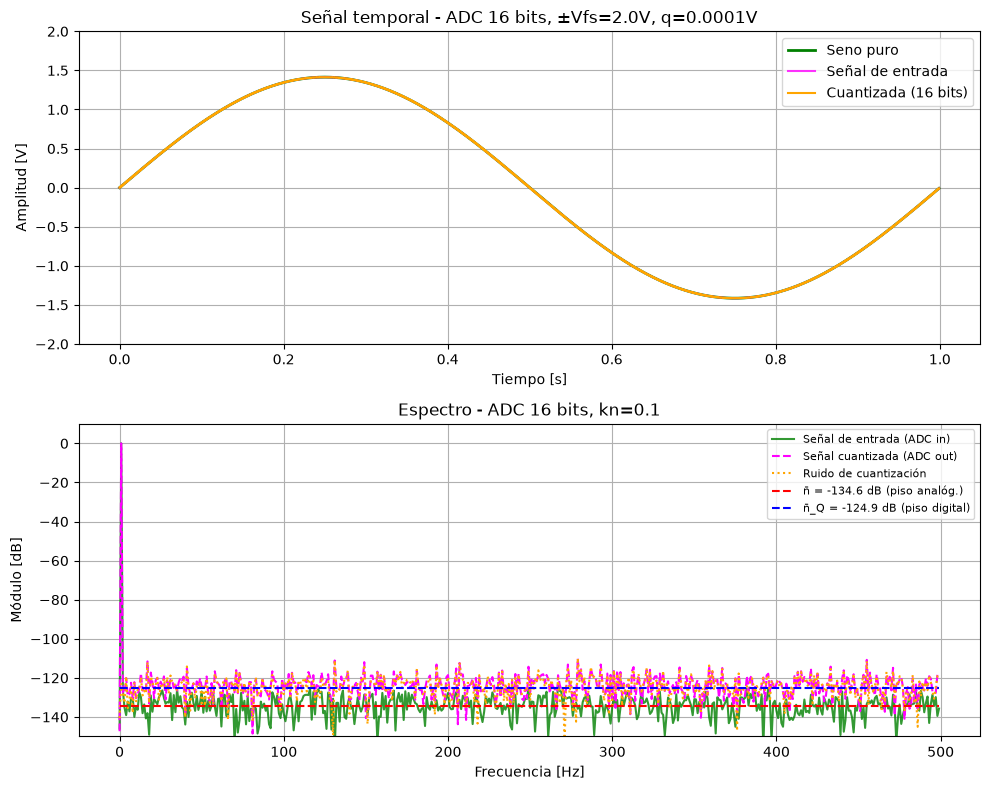

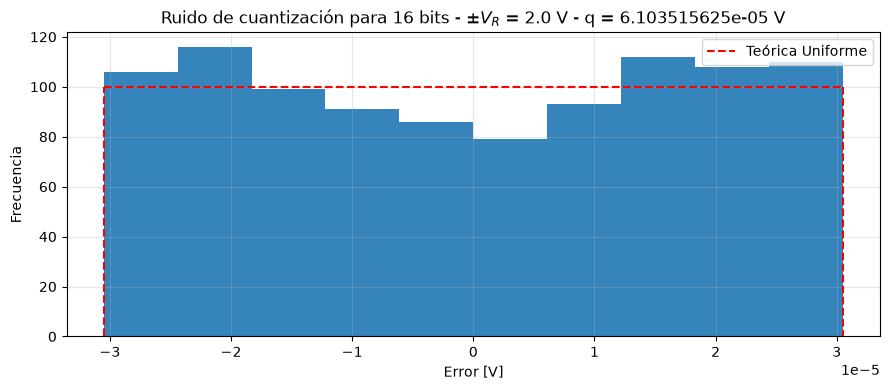

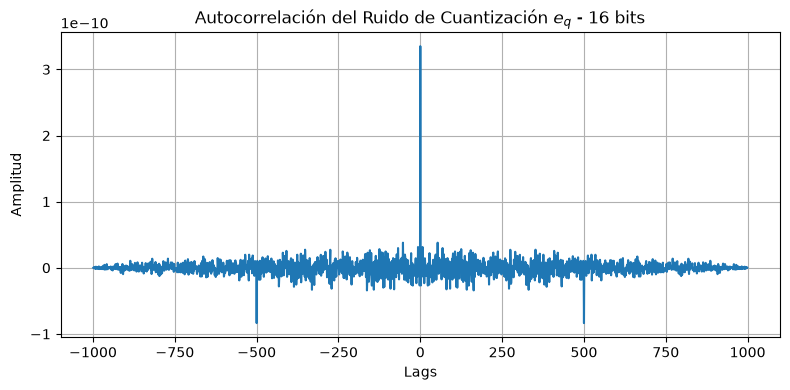

SNR Real del sistema: 94.27 dB

 -------- FACTOR DE ESCALA: 1 --------

Varianza medida de e_n: 3.081e-10 V²  |  Teórica (q²/12): 3.104e-10 V²
KS statistic = 0.0169  |  p-value = 0.9331
→ No se rechaza H0: el error es compatible con U(-q/2, q/2)


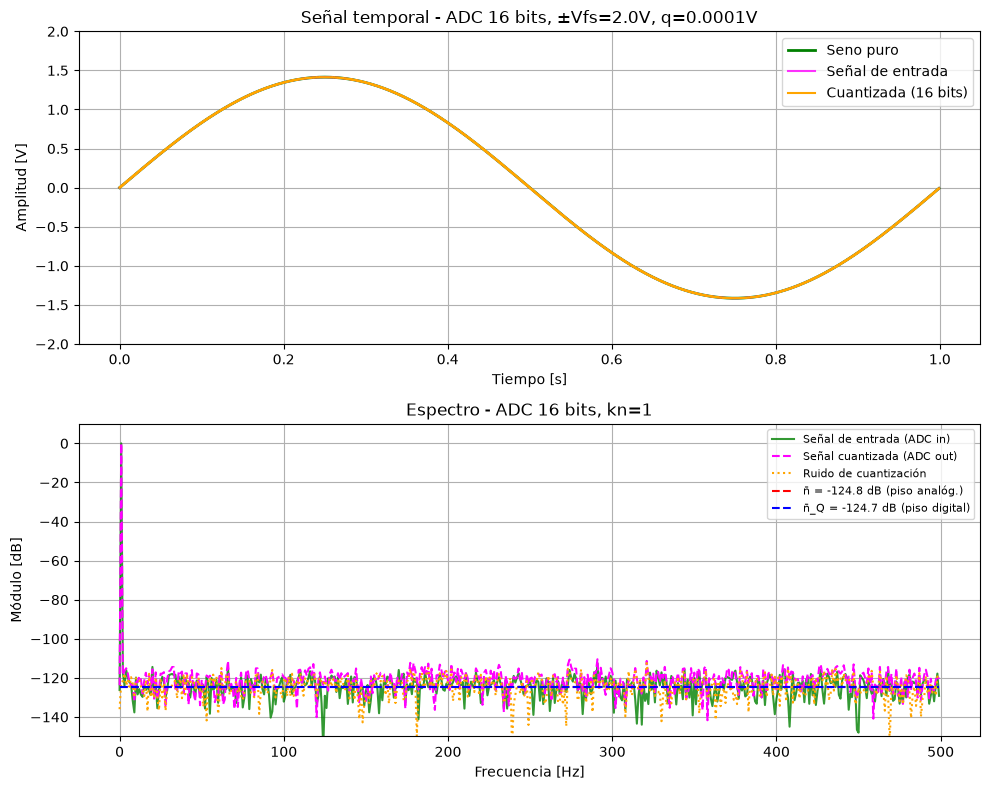

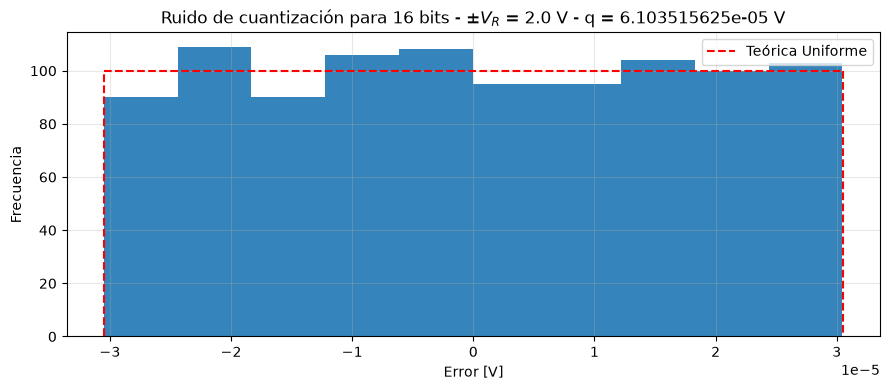

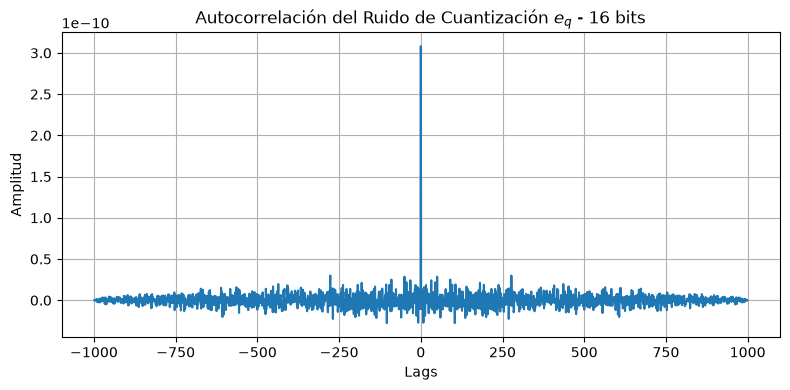

SNR Real del sistema: 91.98 dB

 -------- FACTOR DE ESCALA: 10 --------

Varianza medida de e_n: 3.158e-10 V²  |  Teórica (q²/12): 3.104e-10 V²
KS statistic = 0.0211  |  p-value = 0.7562
→ No se rechaza H0: el error es compatible con U(-q/2, q/2)


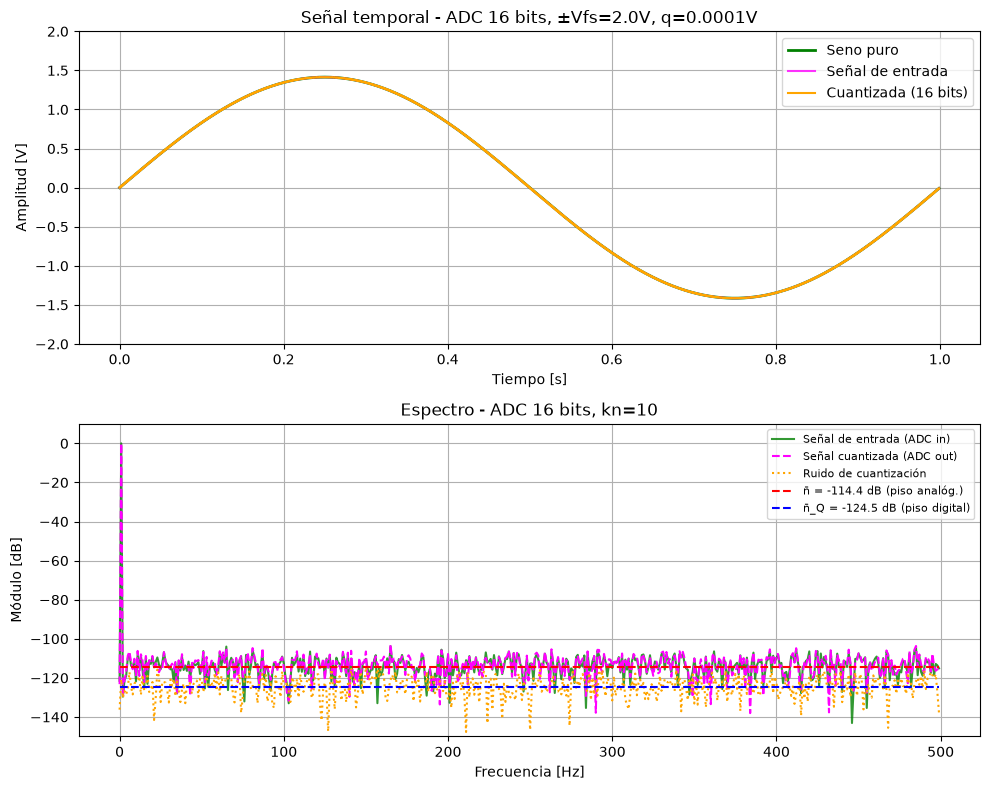

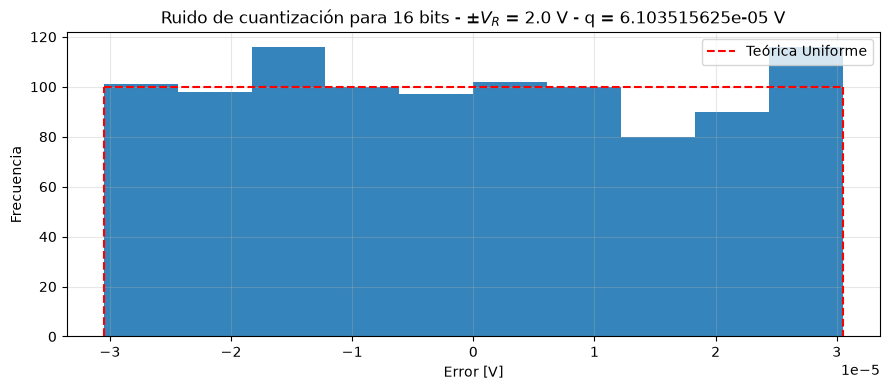

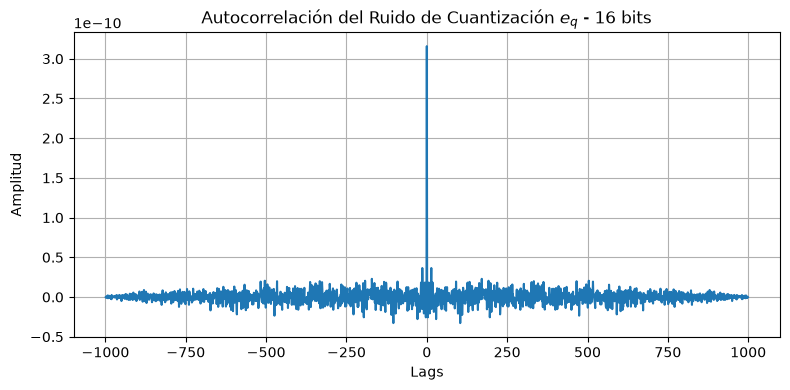

SNR Real del sistema: 84.42 dB


,kn,Var. medida e_n [V²],Var. teórica q²/12 [V²],KS p-value,SNR [dB]
0,0.1,3.351e-10,3.104e-10,0.1928,94.27
1,1.0,3.081e-10,3.104e-10,0.9331,91.98
2,10.0,3.158e-10,3.104e-10,0.7562,84.42


In [23]:
## CASO 2:
resultados_B16 = []
#parametros cuantización
B = 16                   # bits del ADC
kn = [0.1, 1, 10]       # factor k: relación pot. analógica / pot. cuantización
Vfs = 2.0               # rango de fondo de escala (+-Vfs)

#%% 3. SEÑAL DE ENTRADA - CUANTIZACIÓN
# acá solo calculo las señales
tt, xx = funcion_sen(Amplitud, Vmed, ff, phi, N, fs)

# para poder recorrer todo realizo un for (que vaya haciendo los distintos gráficos, los bits lo cambio a mano)
# seguramente haya otras maneras más prolijas de solucionarlo
for i in kn:
    
    print(f"\n -------- FACTOR DE ESCALA: {i} --------\n")
    
    # mido el paso de cuantización y su potencia para calcular Pruido
    q = 2 * Vfs / (2**B)
    Pq = (q**2) / 12
    Pruido = i * Pq #relacion que nos la dan en la consigna

    # Ruido analógico
    # calculo el vector ruido Gaussiano e incorrelado: (media 0,  varianza = la raíz de Pn, cant de muestras a generar)
    dv = np.sqrt(Pruido)
    ruido = np.random.normal(0, dv, N)
    
    # Entrada al ADC con saturación
    señal_entrada = xx + ruido
    señal_sat = np.clip(señal_entrada, -Vfs, Vfs) #recorta/limita los valores de un vector para que queden dentro de ese rango
    
    # Cuantización y error
    # lo del ( ) me dice cuantos pasos q entran en la señal, lo redondeo y vuelvo a volts donde el valor puede ser un multiplo entero de q
    # xx_cuantizada ya no es continua, vale: -2q, -q, 0, q, 2q, ...
    xx_q = np.round(señal_sat / q) * q
    e_n = xx_q - señal_sat
    
    #%% 4. DOMINIO FRECUENCIAS
    # paso al dominio de frecuencias (para poder graficar):
    frecuencias = np.fft.fftfreq(N, 1/fs)
    corte = N // 2
    frec_nyquist = frecuencias[:corte]
    
    # Tomamos como referencia el pico máximo de la señal de entrada al ADC
    fft_entrada_fis = (2 / N) * np.fft.fft(señal_sat)
    fft_entrada_fis[0] = fft_entrada_fis[0] / 2
    modulo_entrada_dB_bruto = 20 * np.log10(np.maximum(np.abs(fft_entrada_fis)[:corte], 1e-12))
    max_referencia = np.max(modulo_entrada_dB_bruto)
    
    # Obtenemos los espectros normalizados para cada señal
    modulo_entrada = espectro_normalizado_dB(señal_sat, max_referencia)
    modulo_ruido_analog = espectro_normalizado_dB(ruido, max_referencia)
    modulo_señalcuanti = espectro_normalizado_dB(xx_q, max_referencia)
    modulo_ruidocuanti = espectro_normalizado_dB(e_n, max_referencia)

    # Pisos de ruido (promediando sin incluir la continua en el índice 0)
    piso_analogico = np.mean(modulo_ruido_analog[1:]) #solo indica que se saltee el 0
    piso_digital = np.mean(modulo_ruidocuanti[1:])
    
    # --- Verificación estadística del error de cuantización ---
    var_medida = np.var(e_n)
    print(f"Varianza medida de e_n: {var_medida:.3e} V²  |  Teórica (q²/12): {Pq:.3e} V²")

    resultado = kstest(e_n, 'uniform', args=(-q/2, q))
    print(f"KS statistic = {resultado.statistic:.4f}  |  p-value = {resultado.pvalue:.4f}")
    if resultado.pvalue > 0.05:
        print("→ No se rechaza H0: el error es compatible con U(-q/2, q/2)")
    else:
        print("→ Se rechaza H0: el error NO parece uniforme")
    
    #%% 5. GRÁFICO 1: DOMINIO TIEMPO
    plt.figure(figsize=(10, 8))
    plt.subplot(2, 1, 1)
    plt.plot(tt, xx, label='Seno puro', color='green', linestyle='-', linewidth=2)
    plt.plot(tt, señal_sat, label='Señal de entrada', color='magenta', linestyle='-', markersize=3, alpha=0.8)
    plt.step(tt, xx_q, where='mid', label=f'Cuantizada ({B} bits)', color='orange', linewidth=1.5)
    plt.title(f"Señal temporal - ADC {B} bits, ±Vfs={Vfs}V, q={q:.4f}V")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Amplitud [V]")
    plt.ylim(-Vfs, Vfs)
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.tight_layout()
    
    #%% 6. GRÁFICO 2: ESPECTRO EN FRECUENCIA [dB]
    plt.subplot(2, 1, 2)
    plt.plot(frec_nyquist, modulo_entrada, label='Señal de entrada (ADC in)', color='green', alpha=0.8)
    plt.plot(frec_nyquist, modulo_señalcuanti, label='Señal cuantizada (ADC out)', linestyle='--', color='magenta')
    plt.plot(frec_nyquist, modulo_ruidocuanti, label='Ruido de cuantización', linestyle=':', color='orange')
    plt.plot(frec_nyquist, [piso_analogico]*len(frec_nyquist), linestyle='--', color='red', label=f'n̄ = {piso_analogico:.1f} dB (piso analóg.)')
    plt.plot(frec_nyquist, [piso_digital]*len(frec_nyquist), linestyle='--', color='blue', label=f'n̄_Q = {piso_digital:.1f} dB (piso digital)')

    plt.title(f'Espectro - ADC {B} bits, kn={i}')
    plt.xlabel('Frecuencia [Hz]')
    plt.ylabel('Módulo [dB]')
    plt.legend(fontsize=8, loc='upper right')
    plt.ylim(-150, 10)
    plt.grid(True)
    plt.tight_layout()
    
    #%% 7. GRAFICO 3: HISTOGRAMA DEL ERROR DE CUANTIZACIÓN
    plt.figure(figsize=(9, 4))

    # 1. Histograma de los errores (usamos 10 bins para mejorar el grafico)
    count, bins, ignored = plt.hist(e_n, bins=10, color='tab:blue', alpha=0.9)

    # 2. Dibujamos la caja roja teórica de la distribución uniforme U(-q/2, q/2)
    # La altura teórica de las cuentas por bin es el total de muestras (nn) dividido la cantidad de bins (10)
    altura_teorica = N / 10

    plt.plot([-q/2, -q/2], [0, altura_teorica], color='red', linestyle='--')
    plt.plot([-q/2,  q/2], [altura_teorica, altura_teorica], color='red', linestyle='--', label='Teórica Uniforme')
    plt.plot([ q/2,  q/2], [altura_teorica, 0], color='red', linestyle='--')

    plt.title(f"Ruido de cuantización para {B} bits - $\pm V_R$ = {Vfs} V - q = {q:} V")
    plt.xlabel("Error [V]")
    plt.ylabel("Frecuencia")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    #%% 8. GRÁFICO 4: AUTOCORRELACIÓN DEL RUIDO DE CUANTIZACIÓN
    plt.figure(figsize=(8, 4))

    r_eq = np.correlate(e_n, e_n, mode='full') / N
    lags = np.arange(-N + 1, N)

    plt.plot(lags, r_eq)
    plt.title(f'Autocorrelación del Ruido de Cuantización $e_q$ - {B} bits')
    plt.xlabel('Lags')
    plt.ylabel('Amplitud')
    plt.grid(True)

    plt.tight_layout()
    plt.show()
    
    #%% 9. SNR:
    e_total = xx_q - xx
    P_s = np.mean(xx**2)
    P_e_total = np.mean(e_total**2)

    SNR_real = 10 * np.log10(P_s / P_e_total)

    print(f"SNR Real del sistema: {SNR_real:.2f} dB")
    
    resultados_B16.append({
    "kn": i,
    "Var. medida e_n [V²]": var_medida,
    "Var. teórica q²/12 [V²]": Pq,
    "KS p-value": resultado.pvalue,
    "SNR [dB]": SNR_real
    })
        
import pandas as pd

tabla = pd.DataFrame(resultados_B16)
tabla   # sin print — Jupyter la muestra como tabla directamente

tabla_mostrar = tabla.copy()
tabla_mostrar["Var. medida e_n [V²]"] = tabla_mostrar["Var. medida e_n [V²]"].map(lambda x: f"{x:.3e}")
tabla_mostrar["Var. teórica q²/12 [V²]"] = tabla_mostrar["Var. teórica q²/12 [V²]"].map(lambda x: f"{x:.3e}")
tabla_mostrar["KS p-value"] = tabla_mostrar["KS p-value"].round(4)
tabla_mostrar["SNR [dB]"] = tabla_mostrar["SNR [dB]"].round(2)
tabla_mostrar


#### Se puede observar:
- Al aumentar la resolución a 16 bits, el SNR vuelve a mejorar en 48dB respecto a los 8 bits (aproximadamente $6 dB/bit$), confirmando la relación teórica de Holton en los tres casos. El piso de ruido en el espectro desciende de forma consistente con este aumento de SNR
- Para $k_n=0,1$ se vuelve a rechazar la hipótesis nula, a diferencia de lo esperado en $B=8$. Sin embargo, a diferencia del rechazo obtenido en $B=4$ (que se lo asoció a la escasez de niveles de cuantización utilizados) este resultado es más inestable, probablemente debido a la sensibilidad del test ante una varianza extremadamente pequeña (aproximadamente $3e-10 V²$) más que a una correlación real entre el error y la señal.

### Si comparamos todos los valores de SNR:

In [24]:
import pandas as pd
import math

#junto los 9 resultados (3 bits x 3 kn) en una sola tabla
tabla_completa = pd.concat([
    pd.DataFrame(resultados_B4),
    pd.DataFrame(resultados_B8),
    pd.DataFrame(resultados_B16)
], ignore_index=True)

tabla_completa.insert(0, "B (bits)", [4]*3 + [8]*3 + [16]*3)

# SNR ideal teórico: el que se tiene sin ruido analógico, solo limitado por cuantización
# SNR_ideal = 10*log10(Ps / Pq),  Pq = q²/12,  q = 2*Vfs/2^B
Ps = 1.0  # potencia de la señal
tabla_completa["SNR ideal [dB]"] = tabla_completa["B (bits)"].apply(
    lambda B: 10*math.log10(Ps / ((2*Vfs/(2**B))**2/12))
)
tabla_completa["Dif. vs ideal [dB]"] = tabla_completa["SNR ideal [dB]"] - tabla_completa["SNR [dB]"]

# formato para mostrar
tabla_final = tabla_completa.copy()
tabla_final["Var. medida e_n [V²]"] = tabla_final["Var. medida e_n [V²]"].map(lambda x: f"{x:.3e}")
tabla_final["Var. teórica q²/12 [V²]"] = tabla_final["Var. teórica q²/12 [V²]"].map(lambda x: f"{x:.3e}")
for col in ["KS p-value", "SNR [dB]", "SNR ideal [dB]", "Dif. vs ideal [dB]"]:
    tabla_final[col] = tabla_final[col].round(4)

tabla_final

,B (bits),kn,Var. medida e_n [V²],Var. teórica q²/12 [V²],KS p-value,SNR [dB],SNR ideal [dB],Dif. vs ideal [dB]
0,4,0.1,5.908e-03,5.208e-03,0.0155,21.7589,22.8330,1.0741
1,4,1.0,5.403e-03,5.208e-03,0.2793,19.5972,22.8330,3.2358
2,4,10.0,5.126e-03,5.208e-03,0.8308,12.5395,22.8330,10.2935
3,8,0.1,2.131e-05,2.035e-05,0.2967,46.2723,46.9154,0.6431
4,8,1.0,2.006e-05,2.035e-05,0.7583,43.7836,46.9154,3.1319
5,8,10.0,2.091e-05,2.035e-05,0.6791,36.5250,46.9154,10.3905
6,16,0.1,3.351e-10,3.104e-10,0.1928,94.2651,95.0802,0.8151
7,16,1.0,3.081e-10,3.104e-10,0.9331,91.9774,95.0802,3.1029
8,16,10.0,3.158e-10,3.104e-10,0.7562,84.4157,95.0802,10.6645


### Conclusión:
Se observa que al aumentar la cantidad de bits mejora sustancialmente el SNR en todos los casos analizados (aproximadamente 6dB por bit adicional, independientemente del valor de $k_n$), siendo este el factor dominante sobre la calidad de la conversión analógico-digital. El factor $k_n$ introduce una degradación menor respecto al SNR ideal, la cual se mantiene proporcional a las tres resoluciones estudiadas. Esto indica que dentro del modelo simulado, la cantidad de bits sigue siendo el parámetro de mayor impacto.